# Part 5 Eval (neglict ci)

## The purpose of this experiment to answer these questions
- Can i reveal the depth map?

# 0) Imports & helpers

In [1]:
# %% Imports
from pathlib import Path
import math, time
import numpy as np
import torch
import matplotlib.pyplot as plt

# your package
from nerflab.nerf_sigma_learning import SigmaMLP, load_model_weights, render_full_opacity
from nerflab import Intrinsics, CFG
from nerflab.io import load_batch_simple, get_frame_ids_for_case

# viz helpers
from nerflab.viz.render import Renderer, BinaryRenderCfg
from nerflab.viz.viz_sigma import visualize_sigma
# from nerflab.viz.plot_nonzero_sigma import plot_nonzero_sigma_row

torch.set_grad_enabled(False)  # just in case


# 1) Config

In [2]:
# %% Config
scene_dir   = Path("../data/data_experiment1")
model_dir   = Path("../data/data_experiment2")
split       = "train"
seed        = 7
num_frames  = 5
frame_offset= 0
device      = "cpu"

ckpt_path   = model_dir / "sigma_best.pt"
idx_frame_render  = 0          # which frame to render/evaluate
idx_ray_render = 55350

# rendering options
want_sigma       = True   # also return per-sample σ
want_samples     = True   # also return (t, delta, pts) for viz
target_seconds   = 1.0    # rough target per render pass; used for auto chunk heuristic
max_chunk        = 1<<17  # absolute cap on rays chunk (131072); lower if you hit OOM

# viz options
max_scatter_points = 5000  # ~R' (rays) × N' (samples) target
max_samples_axis   = 16    # cap samples per ray for scatter
save_binary_png    = True

show_world = False
show_world_interactive = True
if show_world or show_world_interactive:
  world_json_path = "../data/world.json"           # update if your world.json lives elsewhere
  # nerflab imports (ensure your env has nerflab on PYTHONPATH)
  from nerflab import load_world, plot_world
  from nerflab.io import camera_from_loaded_H


# 2) Data

In [3]:
# %% Load data
frame_ids, _ = get_frame_ids_for_case(
    scene_dir, split, seed=seed, num_frames=num_frames, frame_offset=frame_offset
)
batch   = load_batch_simple(scene_dir, frame_ids, device=device)
images  = batch["images"]          # (B, H, W) in [0,1]
H_wc    = batch["H_wc"]            # (B, 4, 4)
B, H, W = images.shape
rng     = torch.Generator(device=device).manual_seed(seed)

print(f"Loaded {B} frames @ {H}x{W}")

Loaded 5 frames @ 480x640


# 3) Model

In [4]:
# %% Model
model = SigmaMLP()  # default config (matches your training unless changed)
_ = load_model_weights(model, str(ckpt_path), device)
model.eval()


Loaded weights from ../data/data_experiment2/sigma_best.pt (step=41200, psnr=27.690330083368483)


SigmaMLP(
  (pe): PosEnc()
  (act): SiLU()
  (layers): ModuleList(
    (0): Linear(in_features=51, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): Linear(in_features=115, out_features=64, bias=True)
  )
  (sigma_linear): Linear(in_features=64, out_features=1, bias=True)
  (softplus): Softplus(beta=1.0, threshold=20.0)
)

# 4) Fast evaluation helpers

In [5]:
# %% Eval helpers
def auto_chunk_size(H: int, W: int, device: str, max_chunk: int = 1<<17, target_s: float = 1.0):
    """
    Heuristic chunk size picker:
    - GPU: scale with pixels; clamp to max_chunk
    - CPU: smaller chunks to keep memory steady
    """
    R = H * W
    if str(device).startswith("cuda"):
        # start bigger on GPU
        base = min(max(1<<15, R // 4), max_chunk)  # 32k .. 131k
    else:
        base = min(max(1<<13, R // 16), max_chunk//4)  # 8k .. 32k
    return int(base)

def eval_frame_opacity_sigma(model, H_row, rng, device, chunk=None, want_sigma=False, want_samples=False):
    """
    Thin wrapper over your render_full_opacity with timing + auto-chunk.
    Returns (img_flat, sigma_full_or_None, samples_or_None, elapsed_s)
    """
    chunk = chunk or auto_chunk_size(H, W, device, max_chunk, target_seconds)
    t0 = time.time()
    out = render_full_opacity(
        model, H_row, rng,
        device=device,
        chunk_rays=chunk,
        return_sigma=want_sigma,
        return_samples=want_samples,
    )
    dt = time.time() - t0

    # normalize tuple return
    if want_sigma and want_samples:
        img_flat, sigma_full, samples = out
    elif want_sigma:
        img_flat, sigma_full = out
        samples = None
    elif want_samples:
        img_flat, samples = out
        sigma_full = None
    else:
        img_flat = out
        sigma_full, samples = None, None

    return img_flat, sigma_full, samples, dt

def mse_psnr(pred_flat: torch.Tensor, gt_img: torch.Tensor):
    """pred_flat: (H*W,), gt_img: (H, W)"""
    
    gt_img = gt_img.cpu()
    pred_flat = pred_flat.cpu()
    pred = pred_flat.view_as(gt_img)
    
    diff = (pred - gt_img).float()
    mse  = float(torch.mean(diff*diff))
    if mse <= 0: return mse, 99.0
    psnr = 10.0 * math.log10(1.0 / mse)
    return mse, psnr


# 5) Render + evaluate the chosen frame

In [6]:
# %% Render & evaluate
H_row = H_wc[idx_frame_render]
img_flat, sigma_full, samples, elapsed = eval_frame_opacity_sigma(
    model, H_row, rng, device,
    chunk=None,  # let it auto-pick
    want_sigma=want_sigma,
    want_samples=want_samples,
)
print(f"Render time: {elapsed:.2f}s  |  opacity shape: {tuple(img_flat.shape)}")

# Evaluation (if GT available)
gt = images[idx_frame_render]  # (H, W)
mse, psnr = mse_psnr(img_flat, gt)
print(f"MSE={mse:.6f}, PSNR={psnr:.2f} dB")

Render time: 5.11s  |  opacity shape: (307200,)
MSE=0.004329, PSNR=23.64 dB


# 6) Viz: opacity map

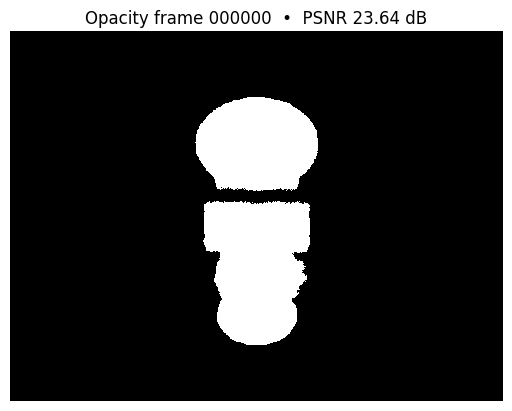

In [7]:
if save_binary_png:
    save_path=str(scene_dir / f"opacity_{frame_ids[idx_frame_render]}.png")
else: 
    save_path = None
rnd = Renderer(BinaryRenderCfg(threshold=0.5))
fig, ax, _ = rnd.binary(
    C=img_flat.view(H, W).cpu().numpy(),
    intr=Intrinsics(**CFG.intrinsics.__dict__),
    title=f"Opacity frame {frame_ids[idx_frame_render]}  •  PSNR {psnr:.2f} dB",
    save_path =save_path,
    )
plt.show()

In [8]:
print(f"min: ", torch.min(sigma_full))
print(f"max: ", torch.max(sigma_full))

min:  tensor(0.)
max:  tensor(573.1194)


In [9]:
if show_world_interactive:
    from nerflab.viz import plot_world_interactive
    try:
        world = load_world(world_json_path)
        cam = camera_from_loaded_H(batch["H_wc"])  
        idx = max(0, min(idx_frame_render, cam.B - 1))
        title = f"World & Camera view (frame idx={idx}, id={frame_ids[idx]})" if idx is not None else "All cam poses"

        idx_per_pose = torch.tensor([[idx_ray_render]], dtype=torch.long)

        fig, _ = plot_world_interactive(
            world,
            cameras=cam,
            cam_indices=[idx] if idx is not None else "all",
            draw_rays=True,
            draw_samples=True,
            # rays_indices=idx_per_pose,
            rays_per_pose=100,
            samples_deterministic=False,
            ray_alpha=0.25,
            samples_alpha=0.1,
            shape_edge_alpha=1.0,
            shape_face_alpha=0.6,
            set_labels=False,
            title=title,
            save_html=f"{scene_dir}/world_view.html",  # interactive output
            show=True,
        )
        # Optional static preview if you also want a PNG (requires `pip install kaleido`)
        # fig.write_image(f"{scene_dir}/world_view.png", scale=2)
    except Exception as e:
        print("[Warn] World Plotly view skipped due to error:", e)


# 7) Viz: σ scatter + heatmap (subsampled safely)

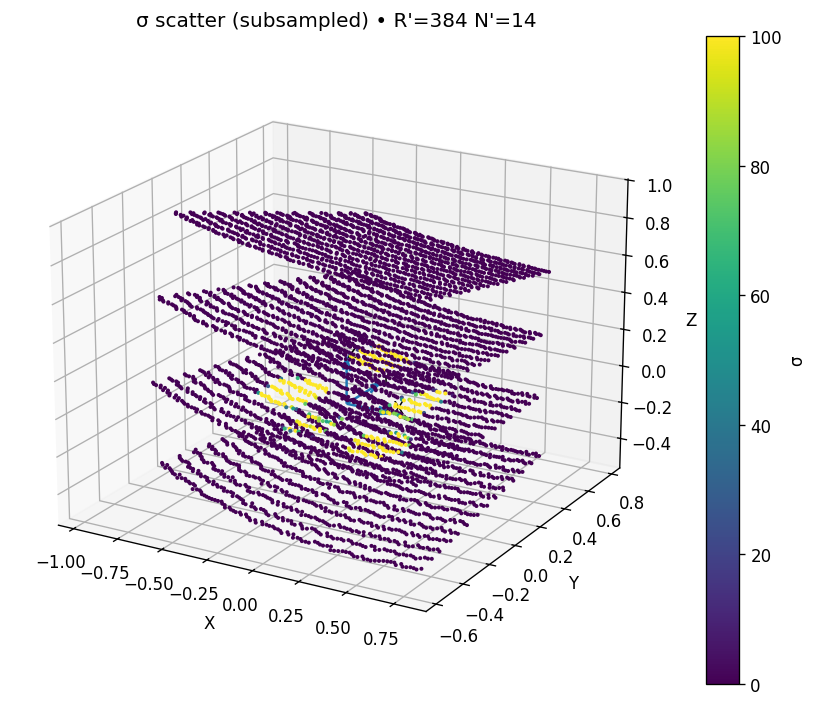

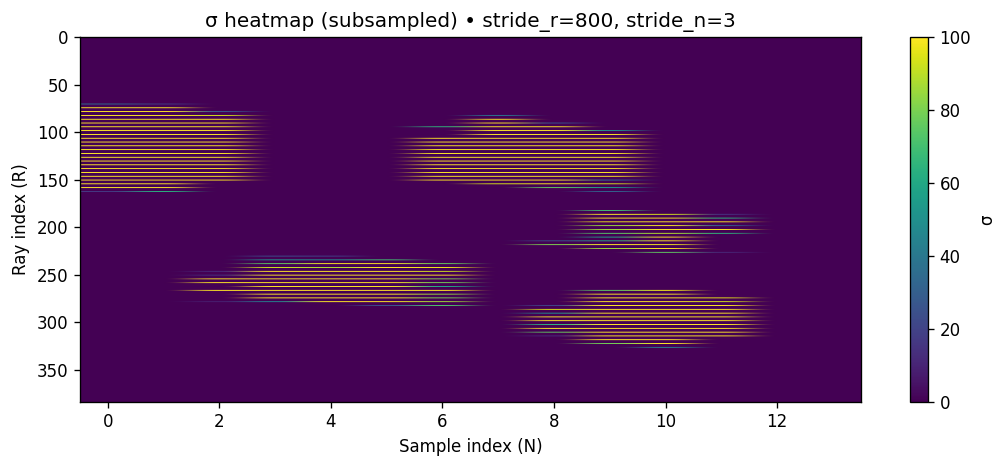

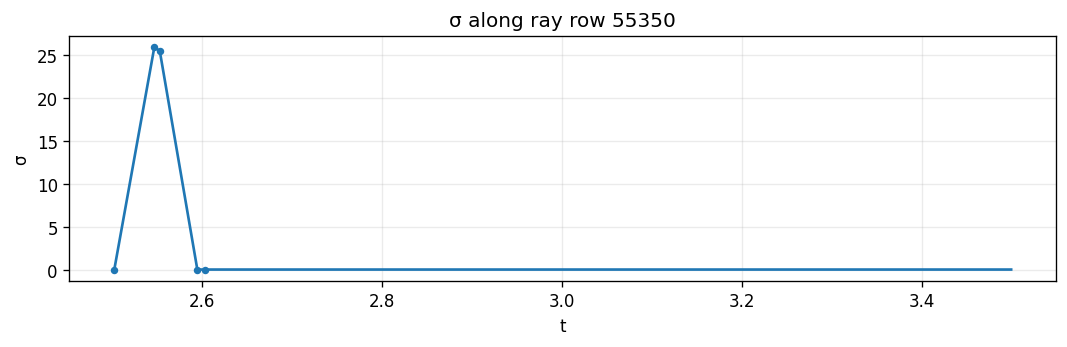

Picked row: 55350 • user‑selected
Row 55350: max σ = 25.938198 at t = 2.547558


In [10]:

# custom: pick a specific ray row and custom titles
_ = visualize_sigma(
    samples, sigma_full,
    idx_ray_render=idx_ray_render,
)

# 8) Viz: Reveal depth map

Depth Map Summary
-----------------
Shape : torch.Size([307200])
Min   : 0.0000
Max   : 3.2696


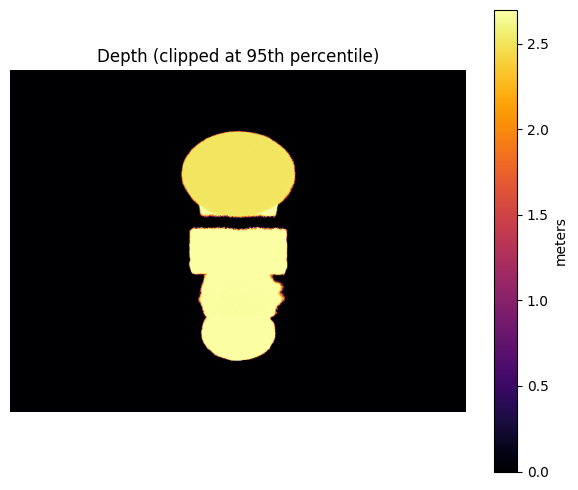

In [11]:
import torch, matplotlib.pyplot as plt

from nerflab.nerf_sigma_learning.ops import render_depth
(t, delta, pts) = samples
depth_map = render_depth(sigma_full, delta, t)
print(
    f"Depth Map Summary\n"
    f"-----------------\n"
    f"Shape : {depth_map.shape}\n"
    f"Min   : {depth_map.min():.4f}\n"
    f"Max   : {depth_map.max():.4f}"
)


# If you know H,W:
D = depth_map.view(H, W)     # reshape

# Optional: clip long tails for nicer contrast (e.g., p95)
hi = torch.quantile(D[D.isfinite()], 0.95).item()
D_vis = torch.clamp(D, 0, hi)

plt.figure(figsize=(6,5))
plt.imshow(D_vis.cpu().numpy(), cmap='inferno')
plt.title("Depth (clipped at 95th percentile)")
plt.axis('off')
plt.colorbar(label='meters')
plt.tight_layout()
plt.show()


## We show that we can reveal the depth map from this expermint. (by know poses)



## lets create another experiment to see if we can reveal depth map from new poses not trained?